In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Colab setup
import os
import sys
from pathlib import Path

DRIVE_PROJECT = "Colab Notebooks/DDL-Diffusion/code"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q diffusers transformers datasets
    from google.colab import drive

    drive.mount("/content/drive")

    drive_root = Path("/content/drive/MyDrive")
    project_dir = drive_root / DRIVE_PROJECT

    if not (project_dir / "scheduler.py").is_file():
        raise RuntimeError(
            f"no scheduler.py under {project_dir} — upload the .py files to that "
            f"folder, or fix DRIVE_PROJECT above"
        )
    os.chdir(project_dir)
# else:
    # Local kernels don't agree on the starting cwd: Jupyter uses the notebook's
    # own directory, PyCharm/VS Code often use the project root. Walk up until we
    # find code/ so the bare `from scheduler import ...` imports and the relative
    # .pt paths resolve either way.
    # start = Path.cwd().resolve()
    # for base in (start, *start.parents):
    #     target = base if base.name == "code" else base / "code"
    #     if (target / "scheduler.py").is_file():
    #         os.chdir(target)
    #         break
    # else:
    #     raise RuntimeError(f"couldn't locate the repo's code/ directory from {start}")

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("colab:", IN_COLAB)
print("cwd  :", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
colab: True
cwd  : /content/drive/MyDrive/Colab Notebooks/DDL-Diffusion/code


In [3]:
import torch
import datasets
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms as T
from diffusers import AutoencoderKL
from tqdm import tqdm
from transformers import CLIPTokenizer, CLIPTextModel

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
device

'cuda'

In [5]:
SEED = 42   # single source of truth: seeds training and the preview sampler

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

In [6]:
poke_data = datasets.load_dataset("diffusers/pokemon-gpt4-captions")

README.md:   0%|          | 0.00/2.21k [00:00<?, ?B/s]

data/train-00000-of-00001-a1df3b486d3a28(…): reconstructing file:   0%|          |  0.00B / 51.1MB            

data/train-00000-of-00001-a1df3b486d3a28(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

In [7]:
print(poke_data)
print(poke_data["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 833
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x1280 at 0x78C155A02390>, 'text': 'A cheerful Bulbasaur ready for its next Pokémon adventure.'}


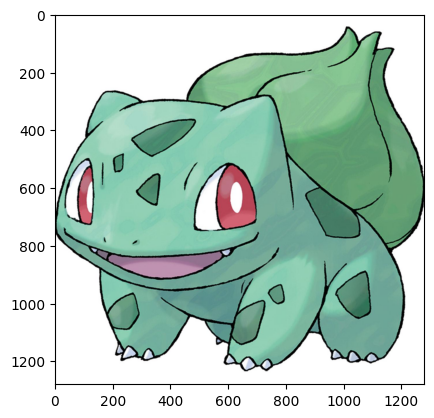

A cheerful Bulbasaur ready for its next Pokémon adventure.


In [8]:
sample = poke_data["train"][0]
plt.imshow(sample["image"])
plt.show()
print(sample["text"])

In [ ]:
# Resolution config.
#
# Run 1 used 512px -> 64x64 latents. That is 16,384 dimensions to model from 833
# images, and it pushed 4096 tokens through self-attention in the top U-Net stage —
# 50% of the whole forward pass. 256px -> 32x32 is 4x cheaper per conv, 16x cheaper
# in top-stage attention, and plenty for a centred creature on a plain background.
RESOLUTION = 256
HFLIP = True                        # also encode mirrored images -> 2x the dataset, free
LATENT_SIZE = RESOLUTION // 8       # the SD VAE downsamples by 8
VAE_SCALE = 0.18215

transforms = T.Compose([
    T.Resize(RESOLUTION),
    T.CenterCrop(RESOLUTION),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def preprocess(image):
    # Returns (3, RESOLUTION, RESOLUTION). Caller adds batch dim if needed.
    return transforms(image)

test_image = preprocess(sample["image"])
print(test_image.shape, "-> latents will be", (4, LATENT_SIZE, LATENT_SIZE))
print(test_image.min(), test_image.max())

In [10]:
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
vae.requires_grad_(False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [ ]:
x = preprocess(poke_data["train"][0]["image"]).unsqueeze(0).to(device)

with torch.no_grad():
    # .mode() not .sample(). We freeze these latents to disk, so a single stochastic
    # posterior draw would bake one fixed noise pattern into every training target
    # forever. The mode is deterministic.
    latent = vae.encode(x).latent_dist.mode() * VAE_SCALE

print(latent.shape)
print(latent.min(), latent.max(), latent.mean(), latent.std())
print("per-channel mean:", [round(v, 3) for v in latent.mean(dim=(0, 2, 3)).tolist()])
print("\nNote how far those per-channel means are from 0. That is the thing the next")
print("cell fixes, and it is the single biggest reason run 1's samples came out wrong.")

In [ ]:
# Encode the WHOLE dataset -> latents.pt + latent_stats.pt
#
# Two changes from run 1, both straight out of the RUNS.md run-2 diagnosis:
#
# 1. PER-CHANNEL NORMALIZATION. The SD latent space has large per-channel offsets —
#    run 1's latents had per-channel means [+1.50, +0.86, +0.03, -0.64]. Decomposing
#    the latent energy: 65.8% of it was a FIXED mean pattern, and 89% of that was
#    just those four constants. So 58.6% of the total signal sat in four numbers.
#    They were also what the trained model got most wrong: generated channel means
#    came out [0.66, 0.37, 0.52, 0.43], an 83% error, with the spread across channels
#    collapsed to 13% of the data's.
#
#    0.18215 is a single global scalar; it only normalizes the OVERALL std. Doing it
#    per channel drops the fixed-pattern share of latent energy from 65.8% to 15.7%
#    and removes the burden entirely. This is what SD3 / Flux do.
#
# 2. HORIZONTAL FLIP. Doubles the dataset for one extra VAE pass. The flip happens in
#    PIXEL space before encoding — flipping a latent is not the same operation.
from precompute import normalize_per_channel

def encode_all(flip):
    out = []
    desc = "flipped" if flip else "originals"
    for i in tqdm(range(0, len(poke_data["train"]), 16), desc=desc):
        imgs = torch.stack([preprocess(im) for im in poke_data["train"][i : i + 16]["image"]])
        if flip:
            imgs = torch.flip(imgs, dims=[-1])
        with torch.no_grad():
            lat = vae.encode(imgs.to(device)).latent_dist.mode() * VAE_SCALE
        out.append(lat.cpu())   # .cpu() is critical — don't hoard on device
    return torch.cat(out, dim=0)

N_ORIGINAL = len(poke_data["train"])
raw_latents = encode_all(flip=False)
if HFLIP:
    # Layout is [originals; flipped], so row i and row i + N_ORIGINAL are the SAME
    # Pokemon. train.make_split relies on that to keep a pair on ONE side of the
    # train/val boundary — otherwise the validation set holds mirrors of training
    # images and the validation loss measures nothing.
    raw_latents = torch.cat([raw_latents, encode_all(flip=True)], dim=0)

print(f"\nraw {tuple(raw_latents.shape)}")
print("  per-chan mean:", [round(v, 3) for v in raw_latents.mean(dim=(0, 2, 3)).tolist()])
print("  per-chan std :", [round(v, 3) for v in raw_latents.std(dim=(0, 2, 3)).tolist()])

latents_tensor, LAT_MEAN, LAT_STD = normalize_per_channel(raw_latents)
print("\nnormalized")
print("  per-chan mean:", [round(v, 4) for v in latents_tensor.mean(dim=(0, 2, 3)).tolist()], "(want ~0)")
print("  per-chan std :", [round(v, 4) for v in latents_tensor.std(dim=(0, 2, 3)).tolist()], "(want ~1)")
print(f"  overall mean {latents_tensor.mean():+.5f}  std {latents_tensor.std():.5f}  "
      f"abs max {latents_tensor.abs().max():.2f}")

torch.save(latents_tensor, "latents.pt")
torch.save({
    "mean": LAT_MEAN, "std": LAT_STD, "scale": VAE_SCALE,
    "resolution": RESOLUTION, "latent_size": latents_tensor.shape[-1],
    "latent_channels": latents_tensor.shape[1], "n_original": N_ORIGINAL,
    "hflip": HFLIP, "normalized": True,
}, "latent_stats.pt")
print("\nsaved latents.pt + latent_stats.pt")

In [ ]:
# Decode a saved latent back to an image — a round-trip check on the normalization.
from sample import latents_to_images

latents = torch.load("latents.pt")
stats = torch.load("latent_stats.pt")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

good = latents_to_images(latents[0:1].to(device), vae,
                         lat_mean=stats["mean"], lat_std=stats["std"])[0].cpu()
axes[0].imshow(good.permute(1, 2, 0).numpy())
axes[0].set_title("normalization undone (correct)")

# Forgetting lat_mean / lat_std is THE mistake to make from here on: the model's
# latent space is no longer the VAE's, so decoding without undoing the shift gives
# off-colour mush. Worth seeing once so you recognise it in a sample later.
bad = latents_to_images(latents[0:1].to(device), vae)[0].cpu()
axes[1].imshow(bad.permute(1, 2, 0).numpy())
axes[1].set_title("lat_mean / lat_std NOT undone")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
CLIP_NAME = "openai/clip-vit-large-patch14"
tokenizer = CLIPTokenizer.from_pretrained(CLIP_NAME)
text_encoder = CLIPTextModel.from_pretrained(CLIP_NAME).to(device)
text_encoder.eval()
text_encoder.requires_grad_(False)




tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.pre_layrnorm.bias                                 | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.

CLIPTextModel(
  (embeddings): CLIPTextEmbeddings(
    (token_embedding): Embedding(49408, 768)
    (position_embedding): Embedding(77, 768)
  )
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (final_layer_norm): LayerNo

In [ ]:
# Verify shape (1, 77, 768).
test_caption = poke_data["train"][0]["text"]

tokens = tokenizer(
    test_caption,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
)
input_ids = tokens.input_ids.to(device)

with torch.no_grad():
    test_emb = text_encoder(input_ids).last_hidden_state

print(test_emb.shape)
print(test_emb.min(), test_emb.max(), test_emb.mean())

torch.Size([1, 77, 768])
tensor(-28.0912, device='cuda:0') tensor(33.0632, device='cuda:0') tensor(-0.1118, device='cuda:0')


In [ ]:
# Encode ALL captions -> embeddings.pt
# Row i of embeddings.pt -> row i of latents.pt.
all_captions = [row["text"] for row in poke_data["train"]]

all_input_ids = tokenizer(
    all_captions,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids

all_embeddings = []
text_batch_size = 32
for i in tqdm(range(0, len(all_captions), text_batch_size)):
    batch_ids = all_input_ids[i : i + text_batch_size].to(device)
    with torch.no_grad():
        emb = text_encoder(batch_ids).last_hidden_state
    all_embeddings.append(emb.cpu())

embeddings_tensor = torch.cat(all_embeddings, dim=0)
if HFLIP:
    # A mirrored Pokemon has the same caption. Tile to match the latent layout.
    embeddings_tensor = torch.cat([embeddings_tensor, embeddings_tensor], dim=0)

assert embeddings_tensor.shape[0] == latents_tensor.shape[0], "caption count must match latent count"
print(embeddings_tensor.shape)
torch.save(embeddings_tensor, "embeddings.pt")

In [ ]:
# Encode the "" -> uncond_embedding.pt
# Used for Classifier-Free Guidance (CFG) during training and inference.
uncond_ids = tokenizer(
    "",
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids.to(device)

with torch.no_grad():
    uncond_embedding = text_encoder(uncond_ids).last_hidden_state

print(uncond_embedding.shape)   # (1, 77, 768)
torch.save(uncond_embedding.cpu(), "uncond_embedding.pt")

torch.Size([1, 77, 768])


In [ ]:
# autoreload makes Jupyter pick up edits to .py files without restarting the kernel.
# %load_ext autoreload
# %autoreload 2
from scheduler import NoiseScheduler

In [ ]:
# The noise schedule. Two changes from run 1, and this cell is where you verify them.
#
# ZERO TERMINAL SNR.  Run 1 had alphas_cumprod[-1] = 0.00158, so
# sqrt(alphas_cumprod[-1]) = 0.0397 and training at t=999 still leaked 0.0397 * x_0
# into x_t. Because the raw latents had per-channel means up to +1.50, that leak was
# a per-channel DC offset — detectable at roughly 4 sigma once averaged over a
# channel's 1024 spatial positions. So the model learned to READ the output's DC
# level off its input instead of GENERATING it. At inference x_T = torch.randn has
# per-channel mean exactly 0, the cue is gone, and the channels collapse together.
# That is the flaw in "Common Diffusion Noise Schedules and Sample Steps are Flawed"
# (Lin et al.); Algorithm 1 there rescales the schedule so alphas_cumprod[-1] = 0.
#
# V-PREDICTION.  Required once alphas_cumprod[-1] = 0: recovering x_0 from an eps
# prediction needs (x_t - sqrt(1-ab) eps) / sqrt(ab), which divides by zero. The v
# route, x_0 = sqrt(ab) x_t - sqrt(1-ab) v, is an exact rotation and finite
# everywhere. It also flattens the loss across t — see the next few cells.
scheduler = NoiseScheduler(zero_terminal_snr=True, prediction_type="v").to(device)
run1 = NoiseScheduler(zero_terminal_snr=False, prediction_type="eps")

rows = [
    ("alphas_cumprod[0]",        run1.alphas_cumprod[0].item(),        scheduler.alphas_cumprod[0].item(),        "want ~1.0"),
    ("alphas_cumprod[-1]",       run1.alphas_cumprod[-1].item(),       scheduler.alphas_cumprod[-1].item(),       "want exactly 0"),
    ("sqrt(alphas_cumprod[-1])", run1.sqrt_alphas_cumprod[-1].item(),  scheduler.sqrt_alphas_cumprod[-1].item(),  "<- the leak"),
    ("betas[0]",                 run1.betas[0].item(),                 scheduler.betas[0].item(),                 ""),
    ("betas[-1]",                run1.betas[-1].item(),                scheduler.betas[-1].item(),                "1.0 is expected here"),
]
print(f"{'':26s} {'run 1':>12} {'run 2':>12}")
for name, a, b, note in rows:
    print(f"{name:26s} {a:12.7f} {b:12.7f}   {note}")

assert scheduler.alphas_cumprod[-1].item() == 0.0, "terminal SNR is not zero"
print("\nx_T is now pure noise by construction — exactly what inference samples from.")

In [ ]:
# Noise one real Pokemon latent across the schedule and decode each step.
#
# The last panel is the one that matters: with zero terminal SNR, t=999 is EXACTLY
# pure noise, with no trace of the Pokemon left. Run 1's schedule kept 3.97% of the
# signal there, and the model quietly came to depend on it.
latents = torch.load("latents.pt")
stats = torch.load("latent_stats.pt")
x_0 = latents[0:1].to(device)

noise = torch.randn_like(x_0)
timesteps_to_show = [0, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(3.2 * len(timesteps_to_show), 3.8))
for ax, t_val in zip(axes, timesteps_to_show):
    t = torch.full((1,), t_val, device=device, dtype=torch.long)
    x_t = scheduler.q_sample(x_0, t, noise)
    img = latents_to_images(x_t, vae, lat_mean=stats["mean"], lat_std=stats["std"])[0].cpu()
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"t = {t_val}\nsqrt(ab) = {scheduler.sqrt_alphas_cumprod[t_val].item():.4f}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Test the U-Net, and price the architecture choice.
#
# What we're checking:
#   1. No shape error, and output shape matches input shape.
#   2. Output is exactly 0 at init (out_conv is zero-init), so the first training
#      loss is a clean 1.0 baseline.
#   3. Parameter count.
#
# Run 1 was base_channels=64, 1 ResNetBlock per stage, self-attention at the top
# resolution. That last item cost 50% of the forward pass, because self-attention is
# O((H*W)^2 * C) and H*W was 4096. Stable Diffusion has no attention at its highest
# resolution for exactly this reason; dropping it here is a measured 1.79x speedup.
# Cross-attention STAYS — it is ~1% of the cost and it is how text reaches full
# resolution. The freed budget goes into width and depth instead:
#
#   config                          latent  params   GFLOP  attn%  samples/hr
#   run 1: base64, 1 blk, top-attn  64x64   12.7M    20.06    50%       1.00x
#   base64,  2 blk, no top-attn     32x32   17.4M     3.69     4%       5.44x
#   base96,  2 blk, no top-attn     32x32   35.5M     7.97     3%       2.52x   <- this
#   base128, 2 blk, no top-attn     32x32   60.1M    13.87     2%       1.45x
from unet import UNet

BASE_CHANNELS = 96
NUM_RES_BLOCKS = 2
TOP_SELF_ATTN = False
DROPOUT = 0.0        # run 1 used 0.1. On a model this far from fitting, dropout is
                     # pure damage — and it inflated every logged training loss.

model = UNet(base_channels=BASE_CHANNELS, num_res_blocks=NUM_RES_BLOCKS,
             top_self_attn=TOP_SELF_ATTN, dropout=DROPOUT).to(device)

B = 2
x = torch.randn(B, 4, LATENT_SIZE, LATENT_SIZE, device=device)
t = torch.randint(0, 1000, (B,), device=device, dtype=torch.long)
c = torch.randn(B, 77, 768, device=device)

with torch.no_grad():
    out = model(x, t, c)

print("Output shape :", tuple(out.shape))
print("Output std   :", out.std().item(), "(0.0 by design — zero-init out_conv)")

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}   (run 1: 12,658,628)")
print(f"Approx size in float32: {n_params * 4 / 1e6:.1f} MB")

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, Subset
from train import make_split

latents_tensor = torch.load("latents.pt")             # per-channel normalized
embeddings_tensor = torch.load("embeddings.pt")       # (N, 77, 768) CLIP-encoded captions
uncond_embedding = torch.load("uncond_embedding.pt")  # (1, 77, 768) CLIP-encoded ""
stats = torch.load("latent_stats.pt")

LAT_MEAN, LAT_STD = stats["mean"], stats["std"]
LATENT_SIZE = stats["latent_size"]
LATENT_SHAPE = (stats["latent_channels"], LATENT_SIZE, LATENT_SIZE)
N_ORIGINAL = stats["n_original"]

print("latents   :", tuple(latents_tensor.shape), latents_tensor.dtype)
print("embeddings:", tuple(embeddings_tensor.shape))
print("uncond    :", tuple(uncond_embedding.shape))
print("per-chan mean:", [round(v, 4) for v in latents_tensor.mean(dim=(0, 2, 3)).tolist()], "(want ~0)")
print("per-chan std :", [round(v, 4) for v in latents_tensor.std(dim=(0, 2, 3)).tolist()], "(want ~1)")

# Held-out split. Run 1 put ALL 833 latents in train_dataset, so nothing in the logs
# could tell fitting apart from memorizing. make_split splits at the ORIGINAL image
# level, so a mirrored copy never lands opposite its original.
VAL_FRAC = 0.1
train_idx, val_idx = make_split(
    n_total=latents_tensor.shape[0], n_original=N_ORIGINAL,
    hflip=stats["hflip"], val_frac=VAL_FRAC, seed=0,
)

# Batch 32, not 4. Run 1's batch was forced down by 4096-token attention at 64x64;
# at 32x32 with no top-stage attention the activations are ~16x smaller. Batch 4 also
# meant CFG dropout at p=0.1 produced 0.4 uncond rows per step — it averages out, but
# very noisily.
BATCH_SIZE = 32
full_dataset = TensorDataset(latents_tensor, embeddings_tensor)
train_loader = DataLoader(
    Subset(full_dataset, train_idx.tolist()),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)

# Kept on CPU; validation_loss moves batches to the device itself.
val_x0 = latents_tensor[val_idx]
val_ctx = embeddings_tensor[val_idx]

uncond_embedding = uncond_embedding.to(device)
print(f"\ntrain {len(train_idx)}   val {len(val_idx)}   batches/epoch {len(train_loader)}")

In [ ]:
from train import build_ema, make_optimizer, make_lr_schedule, pick_amp_dtype

NUM_EPOCHS = 600
WARMUP_STEPS = 500
LR = 2e-4            # up from 1e-4, because the batch is 8x larger
WEIGHT_DECAY = 0.01
EMA_DECAY = 0.9999
EMA_WARMUP = True    # False keeps the EMA near its random init for thousands of steps
CFG_DROPOUT = 0.1
GRAD_CLIP = 1.0

# None is the right value for v-prediction. Min-SNR-gamma is the correct tool for
# eps-prediction, but layered on top of v it peaks where SNR = gamma (alpha_bar 0.833,
# t~116 on this schedule) and decays both ways — pushing 45% of the training signal
# into t=100-250 and 0.4% above t=750, which is the low-noise bias we are removing.
# Unweighted v-loss is already uniform per timestep at the optimum.
MIN_SNR_GAMMA = None

# bf16 needs compute capability >= 8.0. A Colab T4 is 7.5, so "bf16 is free on Colab"
# holds only on an L4 / A100. "auto" picks bf16 where supported and fp16 otherwise.
amp_dtype, AMP = pick_amp_dtype("auto", device=device)

TOTAL_STEPS = NUM_EPOCHS * len(train_loader)

model = UNet(base_channels=BASE_CHANNELS, num_res_blocks=NUM_RES_BLOCKS,
             top_self_attn=TOP_SELF_ATTN, dropout=DROPOUT).to(device)
noise_scheduler = NoiseScheduler(zero_terminal_snr=True, prediction_type="v").to(device)
ema_model = build_ema(model)
optimizer = make_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
lr_scheduler = make_lr_schedule(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS,
)

# fp16 gradients underflow to zero without loss scaling. bf16 has fp32's exponent
# range and must NOT use a scaler.
scaler = torch.amp.GradScaler("cuda") if (amp_dtype is torch.float16 and device == "cuda") else None

# Saved with every checkpoint so the eval section can rebuild the model without
# guessing. Run 1's checkpoints carried no config, which is why re-evaluating one now
# means remembering base_channels=64 / num_res_blocks=1 / top_self_attn=True.
MODEL_CONFIG = {
    "base_channels": BASE_CHANNELS, "num_res_blocks": NUM_RES_BLOCKS,
    "top_self_attn": TOP_SELF_ATTN, "dropout": DROPOUT,
    "prediction_type": "v", "zero_terminal_snr": True,
    "latent_shape": LATENT_SHAPE, "resolution": stats["resolution"],
    "min_snr_gamma": MIN_SNR_GAMMA, "batch_size": BATCH_SIZE, "lr": LR,
}

print(f"Trainable params     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Total steps          : {TOTAL_STEPS:,}  ({NUM_EPOCHS} epochs x {len(train_loader)} batches)")
print(f"Sample presentations : {TOTAL_STEPS * BATCH_SIZE:,}   (run 1: 166,400)")
print(f"Warmup steps         : {WARMUP_STEPS}")
print(f"Peak LR              : {LR}")
print(f"AMP                  : {AMP}   (GradScaler: {scaler is not None})")

In [ ]:
from train import train_step

smoke_losses = []
data_iter = iter(train_loader)

for i in range(5):
    x_0, context = next(data_iter)
    loss = train_step(
        model=model,
        ema_model=ema_model,
        noise_scheduler=noise_scheduler,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        x_0=x_0.to(device),
        context=context.to(device),
        uncond_embedding=uncond_embedding,
        cfg_dropout_prob=CFG_DROPOUT,
        grad_clip=GRAD_CLIP,
        ema_decay=EMA_DECAY,
        min_snr_gamma=MIN_SNR_GAMMA,
        amp_dtype=amp_dtype,
        scaler=scaler,
        step=i if EMA_WARMUP else None,
    )
    smoke_losses.append(loss)
    print(f"step {i}: loss = {loss:.4f}")

# Test passes if the losses are finite and the first one is ~1.0. E[v^2] = 1 for
# unit-variance latents at every t, and out_conv is zero-init, so a healthy run
# starts at exactly the predict-zero baseline. Anything far from 1.0 here means the
# latents are not normalized or the scheduler is misconfigured.
print(f"\nfirst loss {smoke_losses[0]:.4f}  (want ~1.0 — the predict-zero baseline)")

# Re-run the cell ABOVE before real training so the optimizer and LR schedule start clean.

In [ ]:
from pathlib import Path

from tqdm.auto import tqdm
from train import train_step, validation_loss, save_checkpoint, load_checkpoint
from sample import sample_to_image

# These are relative to cwd, which on Colab is your mounted Drive folder — so
# checkpoints and previews land in Drive and survive a runtime disconnect.
CHECKPOINT_DIR = "checkpoints"
CHECKPOINT_EVERY = 50            # save every N epochs
LOG_EVERY = 50                   # update tqdm postfix every N steps
VAL_EVERY = 10                   # eval-mode held-out loss every N epochs
RESUME_PATH = None               # path to a checkpoint .pt, or None to start fresh

# ON, unlike run 1. 200 epochs with zero images is not a run worth repeating: the
# loss curve is a poor proxy for sample quality, and every failure run 1 actually had
# was visible in a single decoded sample.
PREVIEW = True
PREVIEW_EVERY = 20
PREVIEW_STEPS = 50
PREVIEW_CFG = 2.0                # run 1 used 7.5, the SD default for an 860M model
PREVIEW_CFG_RESCALE = 0.7
PREVIEW_ROWS = [0, 1, 2, 3]
PREVIEW_DIR = "previews"


def make_preview(epoch: int) -> None:
    """DDIM samples from the EMA model: save a PNG strip and show it inline."""
    from torchvision.utils import make_grid, save_image

    # SEED comes from the seeding cell near the top, so previews stay comparable
    # across epochs.
    g = torch.Generator(device=device).manual_seed(SEED)
    imgs = sample_to_image(
        model=ema_model,
        scheduler=noise_scheduler,
        vae=vae,
        cond_emb=embeddings_tensor[PREVIEW_ROWS].to(device),
        uncond_emb=uncond_embedding,
        method="ddim",
        guidance_scale=PREVIEW_CFG,
        guidance_rescale=PREVIEW_CFG_RESCALE,
        num_steps=PREVIEW_STEPS,
        latent_shape=LATENT_SHAPE,
        lat_mean=LAT_MEAN,
        lat_std=LAT_STD,
        generator=g,
    ).cpu()

    out_path = Path(PREVIEW_DIR) / f"epoch_{epoch}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    grid = make_grid(imgs, nrow=len(PREVIEW_ROWS))
    save_image(grid, str(out_path))

    plt.figure(figsize=(3.2 * len(PREVIEW_ROWS), 3.6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f"epoch {epoch}  (DDIM {PREVIEW_STEPS}, CFG {PREVIEW_CFG})")
    plt.axis("off")
    plt.show()


start_step = 0
start_epoch = 0
loss_history: list[float] = []
val_history: list[tuple[int, float]] = []

if RESUME_PATH is not None:
    start_step, start_epoch, loss_history = load_checkpoint(
        RESUME_PATH, model, ema_model, optimizer, lr_scheduler,
        map_location=device, scaler=scaler,
    )
    model.to(device)
    ema_model.to(device)
    print(f"resumed from {RESUME_PATH}: step={start_step}, epoch={start_epoch}")

global_step = start_step
running_loss = 0.0
running_count = 0

for epoch in range(start_epoch, NUM_EPOCHS):

    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for x_0, context in pbar:
        loss = train_step(
            model=model,
            ema_model=ema_model,
            noise_scheduler=noise_scheduler,
            optimizer=optimizer,
            lr_scheduler=lr_scheduler,
            x_0=x_0.to(device),
            context=context.to(device),
            uncond_embedding=uncond_embedding,
            cfg_dropout_prob=CFG_DROPOUT,
            grad_clip=GRAD_CLIP,
            ema_decay=EMA_DECAY,
            min_snr_gamma=MIN_SNR_GAMMA,
            amp_dtype=amp_dtype,
            scaler=scaler,
            step=global_step if EMA_WARMUP else None,
        )

        loss_history.append(loss)
        running_loss += loss
        running_count += 1
        global_step += 1

        if global_step % LOG_EVERY == 0:
            pbar.set_postfix(
                loss=f"{running_loss / running_count:.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )
            running_loss = 0.0
            running_count = 0

    # Held-out loss, eval mode, fixed t and noise draw. The train-vs-val gap is the
    # thing run 1 could not measure at all.
    if (epoch + 1) % VAL_EVERY == 0:
        vl = validation_loss(ema_model, noise_scheduler, val_x0, val_ctx,
                             min_snr_gamma=MIN_SNR_GAMMA)
        tl = validation_loss(ema_model, noise_scheduler,
                            latents_tensor[train_idx[: len(val_idx)]],
                            embeddings_tensor[train_idx[: len(val_idx)]],
                            min_snr_gamma=MIN_SNR_GAMMA)
        val_history.append((global_step, vl["weighted"]))
        print(f"epoch {epoch+1}: train {tl['weighted']:.4f}  val {vl['weighted']:.4f}  "
              f"gap {vl['weighted'] - tl['weighted']:+.4f}")

    if (epoch + 1) % CHECKPOINT_EVERY == 0 or epoch + 1 == NUM_EPOCHS:
        ckpt_path = f"{CHECKPOINT_DIR}/epoch_{epoch + 1}.pt"
        save_checkpoint(
            ckpt_path, model, ema_model, optimizer, lr_scheduler,
            step=global_step, epoch=epoch + 1, loss_history=loss_history,
            scaler=scaler, config=MODEL_CONFIG,
        )
        print(f"saved checkpoint -> {ckpt_path}")

    if PREVIEW and (epoch + 1) % PREVIEW_EVERY == 0:
        make_preview(epoch + 1)

print("training complete.")

In [ ]:
# Plot the loss curve, with the held-out loss on the same axes.
losses = np.array(loss_history)
window = max(1, len(losses) // 100)
moving = np.convolve(losses, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.2, label="per-step (train)")
plt.plot(np.arange(window - 1, len(losses)), moving, label=f"moving avg (w={window})")

if val_history:
    vs, vl = zip(*val_history)
    plt.plot(vs, vl, "o-", color="crimson", ms=4, label="held-out (EMA, eval mode)")

plt.axhline(1.0, color="grey", ls=":", lw=1, label="predict-zero baseline")
plt.xlabel("step")
plt.ylabel("v-MSE loss")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# What to read here:
#   - starts at ~1.0 and falls: the objective is wired up correctly
#   - train and held-out tracking each other: still underfitting, keep going
#   - held-out flattening or rising while train falls: memorizing, stop
# And remember run 1's lesson — this curve went 1.05 -> 0.07 and the samples were
# still unusable. It tells you nothing broke. The previews and the checks below tell
# you whether anything was learned.

## Inference & evaluation checks

The training curve above says *nothing broke*. It cannot say whether the model learned
to use the text, or whether it generates anything that looks like a Pokemon. Run 1
proved that the hard way: loss fell 1.05 → 0.07 across 200 epochs and the samples were
still unusable. Everything below answers the real questions from a saved checkpoint.

Order matters — each block is only worth reading if the one before it passed:

1. **Checkpoint + EMA sanity** — is the EMA a real average, or still near its random init?
2. **Loss binned by timestep, train vs held-out** — *where* on the schedule did it learn, and is it memorizing?
3. **Conditioning check** — does swapping the caption change the loss at all?
4. **Samples** — the actual images.
5. **CFG sweep** — does guidance steer, or just saturate?
6. **Sampler cross-check** — do DDIM and DDPM agree?
7. **Novel prompts** — with the starting noise held fixed, so the test measures the prompt.
8. **Memorization check** — generator, or a lookup table?

Requires the cells above for `vae`, `tokenizer`, `text_encoder`, `latents_tensor`,
`embeddings_tensor`, `uncond_embedding`, `train_idx` and `val_idx`. It does **not**
require the training cell to have run in this session — it loads weights from disk and
rebuilds the architecture from the checkpoint's own `config`.

> **What run 1 measured, for comparison.** Every number below has a run-1 counterpart
> in [`RUNS.md`](../RUNS.md). The three that mattered:
>
> - Sampling from training caption #0 landed **124.68** from training latent #0 —
>   0.99× the median distance between two *random different* Pokemon. After 200
>   exposures, its output for a memorized caption was indistinguishable from an
>   unrelated one.
> - Generated per-channel latent means were **83% off**, with the spread across
>   channels collapsed to 13% of the data's. That is the zero-terminal-SNR failure,
>   and it is what per-channel normalization plus the rescaled schedule fix.
> - Best relative shuffled-minus-matched conditioning gap: **13.6%**. Alive, but thin.

In [ ]:
# 1. Load a checkpoint and check the EMA is usable.
import torch.nn.functional as F

from unet import UNet
from scheduler import NoiseScheduler
from sample import sample_ddim, sample_ddpm, latents_to_images

# TODO: point this at the checkpoint you want to evaluate.
CKPT_PATH = "checkpoints/epoch_600.pt"

ckpt = torch.load(CKPT_PATH, map_location=device)
cfg = ckpt.get("config", {})
print(f"checkpoint : {CKPT_PATH}")
print(f"epoch      : {ckpt['epoch']}   step: {ckpt['step']}")
print(f"loss_hist  : {len(ckpt.get('loss_history', []))} entries")
print(f"config     : {cfg}")

# Rebuilt from the checkpoint's OWN config, so this whole section works in a fresh
# runtime without re-running training and without remembering the architecture.
noise_scheduler = NoiseScheduler(
    zero_terminal_snr=cfg.get("zero_terminal_snr", True),
    prediction_type=cfg.get("prediction_type", "v"),
).to(device)
LATENT_SHAPE = tuple(cfg.get("latent_shape", (4, 32, 32)))


def build_from_ckpt(state_dict):
    m = UNet(
        base_channels=cfg.get("base_channels", 96),
        num_res_blocks=cfg.get("num_res_blocks", 2),
        top_self_attn=cfg.get("top_self_attn", False),
        dropout=0.0,     # always 0 at eval
    ).to(device)
    m.load_state_dict(state_dict)
    m.eval()
    return m


# Two models so we can compare the EMA against the live weights.
live_model = build_from_ckpt(ckpt["model"])
eval_ema = build_from_ckpt(ckpt["ema_model"])

# We sample from the EMA, so if the EMA never caught up to the live model its images
# are noise no matter how good the loss curve looked. With EMA_DECAY=0.9999 the warmup
# ramp min(decay, (1+step)/(10+step)) is the binding term for any run shorter than
# ~90k steps, so the two should be close. A relative delta near 1.0 means the EMA is
# still near its random init.
live_flat = torch.cat([p.flatten() for p in live_model.parameters()])
ema_flat = torch.cat([p.flatten() for p in eval_ema.parameters()])
rel_delta = (ema_flat - live_flat).norm().item() / live_flat.norm().item()

print(f"\n|live|              = {live_flat.norm().item():.2f}")
print(f"|ema|               = {ema_flat.norm().item():.2f}")
print(f"|ema - live|/|live| = {rel_delta:.4f}   (want << 1; ~1 = EMA still near init)")

In [ ]:
# 2. Loss binned by timestep — train vs held-out.
#
# v-prediction makes this far easier to read than run 1's eps version. The latents are
# unit-variance now, so E[v^2] = 1 at EVERY t: a model that predicts zero scores
# exactly 1.0 everywhere, and the Bayes-optimal v-loss is also flat. So the reference
# line is 1.0 across the whole schedule, and the SHAPE of the curve tells you where
# the model is failing with no alpha_bar bookkeeping.
#
# Run 1's unweighted eps loss instead ran 0.325 at t=25 down to 0.0014 at t=975 — a
# 232x spread that was almost entirely "which t did this step draw", which is why its
# aggregate 0.07 said so little.
#
# The eps-equivalent column is v_loss * alphas_cumprod[t], for comparison against
# published eps-MSE figures and against run 1's profile.
#
# TRAIN vs HELD-OUT is the check run 1 could not do at all.

EVAL_N = 256
N_BINS = 20

cpu_gen = torch.Generator().manual_seed(1234)

# Both sets get exactly EVAL_N rows, so the shuffled-caption test in the next cell can
# reuse them without a length mismatch.
EVAL_N = min(EVAL_N, len(train_idx), len(val_idx))


def make_eval_set(idx):
    pick = idx[torch.randperm(len(idx), generator=cpu_gen)[:EVAL_N]]
    x0 = latents_tensor[pick]
    # One fixed noise draw, reused for every bin and every model, so differences are
    # never just resampling luck.
    return (x0.to(device), embeddings_tensor[pick].to(device),
            torch.randn(x0.shape, generator=cpu_gen).to(device), pick)


tr_set = make_eval_set(train_idx)
va_set = make_eval_set(val_idx)
print(f"eval set: {EVAL_N} train / {EVAL_N} held-out latents")


@torch.no_grad()
def loss_at_t(m, t_val, eval_set, ctx=None, batch=32):
    """Mean per-element MSE against the scheduler's target at one fixed timestep."""
    x0, default_ctx, noise, _ = eval_set
    ctx = default_ctx if ctx is None else ctx
    total, n = 0.0, 0
    for i in range(0, x0.shape[0], batch):
        xb, cb, nb = x0[i : i + batch], ctx[i : i + batch], noise[i : i + batch]
        t = torch.full((xb.shape[0],), t_val, device=device, dtype=torch.long)
        x_t = noise_scheduler.q_sample(xb, t, nb)
        target = noise_scheduler.get_target(xb, nb, t)
        pred = m(x_t, t, cb)
        total += F.mse_loss(pred, target, reduction="sum").item()
        n += nb.numel()
    return total / n


bin_ts = [int((i + 0.5) * noise_scheduler.T / N_BINS) for i in range(N_BINS)]
tr_curve, va_curve, eps_curve = [], [], []

print(f"{'t':>5} {'train v':>9} {'val v':>9} {'gap':>9} {'train eps-equiv':>16}")
for t_val in bin_ts:
    lt = loss_at_t(eval_ema, t_val, tr_set)
    lv = loss_at_t(eval_ema, t_val, va_set)
    ab = noise_scheduler.alphas_cumprod[t_val].item()
    tr_curve.append(lt)
    va_curve.append(lv)
    eps_curve.append(lt * ab)
    print(f"{t_val:5d} {lt:9.4f} {lv:9.4f} {lv - lt:+9.4f} {lt * ab:16.4f}")

plt.figure(figsize=(10, 4))
plt.plot(bin_ts, tr_curve, "o-", label="train (EMA)")
plt.plot(bin_ts, va_curve, "s--", label="held-out (EMA)", alpha=0.8)
plt.axhline(1.0, color="red", ls=":", label="predict-zero baseline")
plt.xlabel("timestep t")
plt.ylabel("v-MSE (eval mode)")
plt.title("Denoising loss vs timestep — a flat 1.0 means nothing was learned")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

gap = float(np.mean(va_curve)) - float(np.mean(tr_curve))
print(f"\nmean v-loss   train {np.mean(tr_curve):.4f}   held-out {np.mean(va_curve):.4f}   gap {gap:+.4f}")
print("Both near 1.0 with a small gap  -> underfitting; add capacity or steps.")
print("Train well below held-out       -> memorizing; add data or regularization.")

In [ ]:
# 3. Is the model actually using the text?
#
# THE most common silent failure in a from-scratch conditional diffusion model: the
# cross-attention layers learn nothing, the U-Net becomes an unconditional denoiser,
# and CFG at inference just amplifies noise. The loss curve looks completely normal
# when this happens.
#
# Test: same latents, same noise, same t — only the caption changes.
#   matched  = each latent with its own caption
#   shuffled = each latent with someone else's caption
#   uncond   = the "" embedding
#
# Judge the RELATIVE gap, not the absolute one — the absolute loss scale varies with t.
# Run 1's best relative gap was 13.6% (at t=300), with uncond sitting BETWEEN matched
# and shuffled. That is "alive but thin". Beat it.

shuf = torch.randperm(EVAL_N, generator=torch.Generator().manual_seed(7))
# Guard against a fixed point mapping a row back to its own caption.
assert (shuf == torch.arange(EVAL_N)).sum().item() < EVAL_N * 0.05

tr_ctx = tr_set[1]
shuffled_ctx = tr_ctx[shuf.to(tr_ctx.device)]
uncond_ctx = uncond_embedding.to(device).expand(EVAL_N, -1, -1)

print(f"{'t':>5}  {'matched':>9}  {'shuffled':>9}  {'uncond':>9}  {'gap':>9}  {'relative':>9}")
rel_gaps = []
for t_val in [50, 150, 300, 500, 700, 900]:
    l_match = loss_at_t(eval_ema, t_val, tr_set)
    l_shuf = loss_at_t(eval_ema, t_val, tr_set, ctx=shuffled_ctx)
    l_unc = loss_at_t(eval_ema, t_val, tr_set, ctx=uncond_ctx)
    g = l_shuf - l_match
    rel_gaps.append(g / max(l_match, 1e-12))
    print(f"{t_val:5d}  {l_match:9.4f}  {l_shuf:9.4f}  {l_unc:9.4f}  {g:+9.4f}  {g / max(l_match, 1e-12):8.1%}")

best = max(rel_gaps)
print(f"\nlargest RELATIVE shuffled-minus-matched gap: {best:.1%}   (run 1: 13.6%)")
if best < 0.01:
    print("=> CONDITIONING IS DEAD. The caption does not change the prediction.")
    print("   No CFG value will help. Fix training before reading anything into the samples.")
elif best < 0.05:
    print("=> WEAK conditioning. Text barely registers; expect prompt-insensitive samples.")
else:
    print("=> Conditioning is live. The model does read the caption.")

In [ ]:
# 4. Helpers: encode arbitrary prompts, generate, and show a row of decoded samples.

CFG = 2.0            # TODO: set from the sweep two cells down. Run 1's 7.5 was far too high.
CFG_RESCALE = 0.7    # Lin et al. section 3.4 — counteracts CFG over-exposure
CLIP_X0 = 4.6        # TODO: re-derive for your latents; printed at the end of this cell


@torch.no_grad()
def encode_prompt(prompts):
    """list[str] -> (B, 77, 768) CLIP embeddings, same pipeline as the training data."""
    if isinstance(prompts, str):
        prompts = [prompts]
    ids = tokenizer(
        prompts,
        padding="max_length",
        max_length=77,
        truncation=True,
        return_tensors="pt",
    ).input_ids.to(device)
    return text_encoder(ids).last_hidden_state


@torch.no_grad()
def generate(cond_emb, method="ddim", num_steps=50, guidance_scale=None,
             guidance_rescale=None, eta=0.0, seed=42, fixed_noise=False):
    """
    Sample latents and return (images in [0,1], raw latents). Uses the EMA model.

    fixed_noise=True gives EVERY row the SAME starting noise. Use it for any test that
    compares PROMPTS. Run 1's "prompt-independent collapse" check drew fresh noise per
    row, so its pairwise latent distances measured the noise draw, not the caption --
    the test could not have failed.
    """
    gs = CFG if guidance_scale is None else guidance_scale
    gr = CFG_RESCALE if guidance_rescale is None else guidance_rescale
    g = torch.Generator(device=device).manual_seed(seed)

    B = cond_emb.shape[0]
    x_T = None
    if fixed_noise:
        x_T = torch.randn(1, *LATENT_SHAPE, device=device, generator=g).expand(B, -1, -1, -1).contiguous()

    kw = dict(guidance_scale=gs, guidance_rescale=gr, num_steps=num_steps,
              latent_shape=LATENT_SHAPE, clip_x0=CLIP_X0, x_T=x_T, generator=g)
    if method == "ddim":
        lat = sample_ddim(eval_ema, noise_scheduler, cond_emb,
                          uncond_embedding.to(device), eta=eta, **kw)
    else:
        lat = sample_ddpm(eval_ema, noise_scheduler, cond_emb,
                          uncond_embedding.to(device), **kw)

    imgs = latents_to_images(lat, vae, lat_mean=LAT_MEAN, lat_std=LAT_STD).cpu()
    return imgs, lat


def show_row(images, titles, suptitle=None, wrap=28):
    """images: (B, 3, H, W) in [0, 1]."""
    n = images.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.8))
    axes = [axes] if n == 1 else list(axes)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
        wrapped = "\n".join(str(title)[i : i + wrap] for i in range(0, min(len(str(title)), wrap * 3), wrap))
        ax.set_title(wrapped, fontsize=8)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    plt.show()


def latent_stats(name, lat):
    """
    Compare generated latent statistics against the training latents.

    Because latents.pt is per-channel normalized, the target is now simply
    mean 0.00 / std 1.00 per channel. That is a much easier number to eyeball than
    run 1's raw space, where the reference was per-channel mean
    [+1.50, +0.86, +0.03, -0.64] and a generated latent at mean 0 / std 1 was WRONG.

    Two failure signatures to watch for:
      - std well below 1.0            -> over-smoothed, the classic flat-output failure
      - per-channel means far from 0  -> the zero-terminal-SNR DC problem is back
    Neither is visible in the loss curve.
    """
    pc_mean = lat.mean(dim=(0, 2, 3)).tolist()
    pc_std = lat.std(dim=(0, 2, 3)).tolist()
    print(f"{name:22s} mean={lat.mean().item():+.4f} std={lat.std().item():.4f}  "
          f"per-chan mean={[round(v, 2) for v in pc_mean]}  std={[round(v, 2) for v in pc_std]}")


latent_stats("TRAINING (reference)", latents_tensor)
q = latents_tensor.abs().flatten().float().quantile(torch.tensor([0.9999])).item()
print(f"\nsuggested CLIP_X0 = {q:.1f}   (99.99th pct of |x_0|; abs max {latents_tensor.abs().max():.1f})")

In [ ]:
# 5. THE inference check: sample from captions the model actually trained on.
#
# This is the easiest possible ask — these exact captions were seen every epoch.
# If these do not look like Pokemon, nothing else will.

N_SHOW = 4
show_rows = list(range(N_SHOW))
captions = [poke_data["train"][i]["text"] for i in show_rows]
cond = embeddings_tensor[show_rows].to(device)

imgs, lats = generate(cond, method="ddim", num_steps=50, seed=SEED)
latent_stats(f"generated (cfg {CFG})", lats)
show_row(imgs, captions, suptitle=f"DDIM 50 steps, CFG {CFG} (rescale {CFG_RESCALE}) — training captions")

# Side by side with the real image each caption came from, as a target to compare against.
real = torch.stack([preprocess(poke_data["train"][i]["image"]) for i in show_rows])
show_row((real + 1) / 2, captions, suptitle="Ground truth for the same captions")

In [ ]:
# 6. CFG sweep — same seed, same prompt, varying guidance.
#
# w=1.0 is plain conditional sampling (no guidance). Higher w pushes harder toward the
# caption at the cost of saturation and artifacts. 7.5 is the Stable Diffusion default,
# but SD is an 860M-param model trained on billions of images.
#
# Run 1's measured latent statistics, correlating the 4 generated channel means against
# the training data's:
#
#   CFG    chan-mean spread (% of data)   Pearson r vs data
#   1.0              27%                        +0.83
#   2.0              22%                        +0.79
#   4.0              13%                        +0.51
#   7.5              17%                        -0.63     <- pattern INVERTED
#  15.0              54%                        -0.72
#
# Above ~4 the guidance restored magnitude while inverting the pattern. That is the
# saturation, and no CFG value fixed it — the cause was the schedule, not the sweep.
# Now that per-channel normalization and zero terminal SNR are in, re-run this and
# pick the lowest w that still shows prompt adherence.
#
# Also a conditioning check by another route: if every column looks IDENTICAL,
# pred_cond == pred_uncond and the guidance term is doing nothing.

CFG_ROW = 0
cfg_caption = poke_data["train"][CFG_ROW]["text"]
cfg_cond = embeddings_tensor[CFG_ROW : CFG_ROW + 1].to(device)

print(f"prompt: {cfg_caption}\n")
scales = [1.0, 1.5, 2.0, 3.0, 5.0, 7.5]

for rescale in [0.0, CFG_RESCALE]:
    cfg_imgs = []
    print(f"--- guidance_rescale = {rescale} ---")
    for w in scales:
        img, lat = generate(cfg_cond, method="ddim", num_steps=50, guidance_scale=w,
                            guidance_rescale=rescale, seed=SEED)
        latent_stats(f"cfg {w}", lat)
        cfg_imgs.append(img[0])
    show_row(torch.stack(cfg_imgs), [f"CFG {w}" for w in scales],
             suptitle=f"Guidance sweep, rescale={rescale} (same seed)")

In [ ]:
# 7. Sampler cross-check: DDIM step count, DDIM vs DDPM, and eta.
#
# Both samplers reverse the SAME trained model, so they should produce recognisably
# similar images. Disagreement localises the problem:
#   - DDPM(1000) fine but DDIM(50) broken -> the strided alpha_bar grid math is wrong
#   - both broken but per-timestep loss looked healthy -> a sampler bug, not training
#   - DDIM(50) a bit worse than DDIM(250) -> just discretization error, expected
#
# Run 1 saw something more specific: DDIM at eta=0 drifted toward the conditional mean
# (per-channel mean spread 13-27% of the data's) while DDPM-1000 tracked the data much
# better (38%, r=+0.88). The injected noise keeps the trajectory in-distribution. So if
# the deterministic samples look flat, try eta=1.0 BEFORE blaming the model.
#
# DDPM at 1000 steps is 1000 U-Net calls at batch 2 (CFG doubles the batch), so this
# cell is the slow one in this section.

sweep_cond = embeddings_tensor[0:1].to(device)

variants = [
    ("ddim", 25, 0.0), ("ddim", 50, 0.0), ("ddim", 250, 0.0),
    ("ddim", 50, 1.0), ("ddpm", 1000, 0.0),
]

sweep_imgs, sweep_titles = [], []
for method, steps, eta in variants:
    img, lat = generate(sweep_cond, method=method, num_steps=steps, eta=eta, seed=SEED)
    label = f"{method} {steps}" + (f" eta{eta}" if eta else "")
    latent_stats(label, lat)
    sweep_imgs.append(img[0])
    sweep_titles.append(label.upper())

show_row(torch.stack(sweep_imgs), sweep_titles,
         suptitle=f"Sampler comparison (CFG {CFG}, same seed)")

In [ ]:
# 8. Novel prompts — the only test of generalization the samples can give.
#
# Captions the model has never seen. 833 images is far too few to expect real
# compositional generalization, so treat anything coherent here as a bonus. The useful
# signal is DIFFERENCE: if a red fire dragon and a blue water turtle come out looking
# the same, the model collapsed to a prompt-independent average.
#
# fixed_noise=True is the whole point of this cell. Run 1 drew fresh noise for each
# row, so its "pairwise latent L2 between samples" measured the noise draw and could
# not have detected collapse — four different noises give four different outputs no
# matter what the model does with the caption. With the starting noise pinned, every
# difference below is attributable to the prompt.

novel = [
    "a red fire dragon pokemon with large wings",
    "a blue water turtle pokemon with a hard shell",
    "a small yellow electric mouse pokemon",
    "a green grass pokemon with a flower on its back",
]
novel_cond = encode_prompt(novel)

novel_imgs, novel_lats = generate(novel_cond, method="ddim", num_steps=50,
                                  seed=SEED, fixed_noise=True)
latent_stats("generated (novel)", novel_lats)
show_row(novel_imgs, novel, suptitle=f"Unseen prompts, SHARED starting noise (DDIM 50, CFG {CFG})")

flat = novel_lats.flatten(1)
dist = torch.cdist(flat, flat).cpu()
print("\npairwise latent L2 between samples (same x_T, so this is prompt effect only):")
print(dist.numpy().round(2))
off = dist[~torch.eye(len(novel), dtype=bool)]
print(f"mean off-diagonal: {off.mean().item():.2f}")

# Reference: the same four prompts with INDEPENDENT noise. The ratio is the useful
# number — if shared-noise distances are a tiny fraction of independent-noise ones,
# the prompt is barely steering anything.
_, indep_lats = generate(novel_cond, method="ddim", num_steps=50, seed=SEED, fixed_noise=False)
iflat = indep_lats.flatten(1)
idist = torch.cdist(iflat, iflat).cpu()
ioff = idist[~torch.eye(len(novel), dtype=bool)]
print(f"same prompts, independent noise: mean off-diagonal {ioff.mean().item():.2f}")
print(f"prompt effect / total variation : {off.mean().item() / ioff.mean().item():.1%}")

In [ ]:
# 9. Memorization check — generator, or a lookup table?
#
# The model has now seen each training latent hundreds of times, so this is a real
# risk, and NOTHING in the loss curve can tell you which one you got. For each
# generated latent, find the nearest training latent and look at them together.
#
# Thresholds are recomputed at runtime rather than hardcoded: run 1's 98.69 / 18.79
# were measured on RAW 64x64 latents and mean nothing in this normalized 32x32 space.
#
# Two tiers, both derived from the training set's own geometry:
#   dist < p1   -> suspicious: closer than 99% of genuine distinct pairs. Inspect.
#   dist < min  -> unambiguous copy: closer than the two nearest real images.
#
# Run 1 scored 0.99-1.24x the median here — no memorization at all, which combined
# with a train loss far above the achievable floor is what identified it as an
# UNDERFIT rather than a dataset-size problem.

train_flat = latents_tensor[train_idx].flatten(1)
train_d = torch.cdist(train_flat, train_flat)
off_diag = train_d[~torch.eye(train_flat.shape[0], dtype=torch.bool)]
P1 = off_diag.quantile(0.01).item()
MINDIST = off_diag.min().item()
MEDIAN = off_diag.median().item()

print(f"train-vs-train latent L2: mean {off_diag.mean():.2f}  median {MEDIAN:.2f}  "
      f"p1 {P1:.2f}  min {MINDIST:.2f}")
print(f"  -> suspicious below {P1:.2f}, unambiguous copy below {MINDIST:.2f}\n")


@torch.no_grad()
def nearest_training_latent(gen_lat):
    """Return (indices into train_idx, distances) over the training latents."""
    d = torch.cdist(gen_lat.flatten(1).cpu(), train_flat)
    dist, idx = d.min(dim=1)
    return idx, dist


gen_imgs, gen_lats = generate(embeddings_tensor[0:4].to(device), num_steps=50, seed=SEED)
nn_pos, nn_dist = nearest_training_latent(gen_lats)
nn_rows = train_idx[nn_pos]

for i, (row, d) in enumerate(zip(nn_rows.tolist(), nn_dist.tolist())):
    orig = row % N_ORIGINAL
    tag = " (mirrored copy)" if row >= N_ORIGINAL else ""
    flag = "  <-- COPY" if d < MINDIST else ("  <-- suspicious, inspect" if d < P1 else "")
    print(f"sample {i}: nearest train row {row:4d} = image {orig:3d}{tag}  "
          f"dist {d:7.2f}  ({d / MEDIAN:.2f}x median){flag}")

# Also: is it closer to the training set than to held-out images? A big asymmetry is
# memorization even when no single distance trips the threshold above.
val_flat = latents_tensor[val_idx].flatten(1)
d_val = torch.cdist(gen_lats.flatten(1).cpu(), val_flat).min(dim=1).values
print(f"\nmean nearest distance to TRAIN {nn_dist.mean():.2f}   to HELD-OUT {d_val.mean():.2f}"
      f"   ratio {nn_dist.mean() / d_val.mean():.3f}  (want ~1.0)")

nn_real = torch.stack([preprocess(poke_data["train"][r % N_ORIGINAL]["image"]) for r in nn_rows.tolist()])
nn_real = torch.stack([torch.flip(im, dims=[-1]) if r >= N_ORIGINAL else im
                       for im, r in zip(nn_real, nn_rows.tolist())])
show_row(gen_imgs, [f"generated {i}" for i in range(len(nn_rows))], suptitle="Generated")
show_row((nn_real + 1) / 2, [f"nearest train #{r % N_ORIGINAL}" for r in nn_rows.tolist()],
         suptitle="Nearest training image (latent L2)")